In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

In [2]:
distance = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
times = torch.tensor([[6.96],[12.11],[16.72],[22.21]], dtype=torch.float32)

In [3]:
# Single neuron model
model = nn.Sequential(
    nn.Linear(1, 1)  # One input feature and one output
)

In [4]:
loss_function = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent optimizer

In [5]:
# Training Loop
num_epochs = 1000
for i in range(num_epochs):
    # Forward pass
    predictions = model(distance) # Predictions from the model
    loss = loss_function(predictions, times) # loss_function(predicted, true)

    # Backward pass and optimization
    optimizer.zero_grad() # Clear gradients
    loss.backward() # calculate gradients
    optimizer.step() # Update the model parameters

    if (i+1) % 100 == 0:
        print(f'Epoch [{i+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.0427
Epoch [200/1000], Loss: 0.0381
Epoch [300/1000], Loss: 0.0355
Epoch [400/1000], Loss: 0.0341
Epoch [500/1000], Loss: 0.0334
Epoch [600/1000], Loss: 0.0329
Epoch [700/1000], Loss: 0.0327
Epoch [800/1000], Loss: 0.0326
Epoch [900/1000], Loss: 0.0325
Epoch [1000/1000], Loss: 0.0325


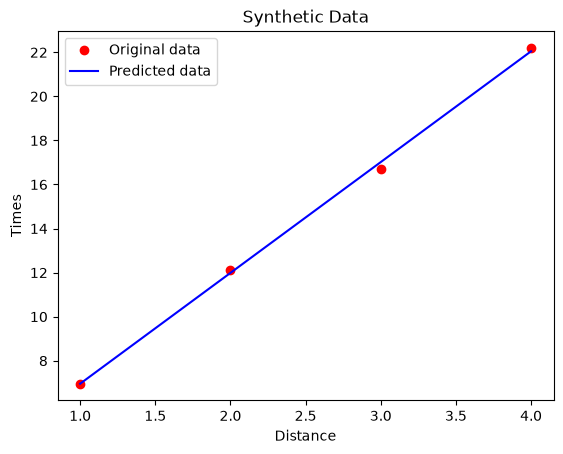

In [7]:
import matplotlib.pyplot as plt

with torch.inference_mode():
    predicted_times = model(distance)

plt.plot(distance, times, 'ro', label='Original data')
plt.plot(distance, predicted_times, 'b-', label='Predicted data')
plt.xlabel('Distance')
plt.ylabel('Times')
plt.title('Synthetic Data')
plt.legend()
plt.show()

In [8]:
test_distance = torch.tensor([[7.0]], dtype=torch.float32)

with torch.no_grad():
    predicted_time = model(test_distance)
    print(f'Predicted time for distance {test_distance.item()}: {predicted_time.item():.4f}')

    # Use tensor.item() to get the scalar value from the tensor, predicted_time is a tensor with shape [1, 1], so we use .item() to extract the scalar value for comparison.
    if predicted_time.item() > 30:
        print("\n Decision: Do NOT take the job. You will likely be late.")
    else:
        print("\n Decision: Take the job. You can make it.")

Predicted time for distance 7.0: 37.1390

 Decision: Do NOT take the job. You will likely be late.


In [13]:
# Checking model parameters value
# First access the layer of which parameter want to check
layer = model[0]  # Access the first layer of the model

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f'Weights: {weights}, Bias: {bias}')

Weights: [[5.0303316]], Bias: [1.9266652]
